<a href="https://colab.research.google.com/github/Kkurzo/-labs/blob/main/%22%D0%9B%D0%A05_%D1%87%D0%B0%D1%81%D0%BE%D0%B2%D1%96_%D1%80%D1%8F%D0%B4%D0%B8_%D1%88%D0%B0%D0%B1%D0%BB%D0%BE%D0%BD_%D0%9C%D0%B5%D0%BB%D1%8C%D0%BD%D0%B8%D1%87%D1%83%D0%BA_%D0%94%D0%BC%D0%B8%D1%82%D1%80%D0%BE_%D0%A4%D0%86%D0%A24_10_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Daily Weather Time Series Data - Delhi, India**

https://www.kaggle.com/datasets/yug201/daily-climate-time-series-data-delhi-india?select=kaggel_weather_2013_to_2024.csv

**Тема:** Прогнозування часових рядів на основі кліматичних даних

**Мета роботи:**
Навчитися виконувати аналіз часових рядів, проводити дослідницький аналіз даних (EDA), визначати автокореляційні залежності, будувати моделі прогнозування та оцінювати їхню точність.

**Вихідні дані**

Для виконання роботи використовується датасет Daily Climate Time Series Data (Delhi, India) з платформи Kaggle, який містить щоденні кліматичні показники (температура, вологість, опади тощо) за кілька років.


1. Завантажити датасет з Kaggle.

2. Імпортувати дані у середовище Python (Jupyter Notebook або Google Colab).

3. Ознайомитися зі структурою датасету (head(), info(), describe()).

4. Попередня обробка даних

-Перетворити колонку з датою у формат datetime.

-Відсортувати дані за датою.

-Встановити дату як індекс часового ряду.

-Перевірити наявність пропущених значень та за необхідності обробити їх.

5. Дослідницький аналіз даних (EDA)

-Побудувати графік зміни температури у часі.

-Побудувати ковзне середнє значення температури.

-Побудувати гістограму розподілу температури.

-Побудувати boxplot для виявлення можливих викидів.

-Аналіз автокореляції

Побудувати графік автокореляційної функції (ACF).

Побудувати графік часткової автокореляції (PACF).

-Проаналізувати залежність значень часового ряду від попередніх періодів.

6.Підготовка даних для моделювання

-Розділити дані на тренувальну та тестову вибірки (наприклад, 80% / 20%).

7. Побудувати щонайменше три моделі прогнозування:

-ARIMA (класична статистична модель);

-Prophet (модель прогнозування часових рядів від Meta);

-LSTM (нейронна мережа для послідовних даних).

8. Оцінка моделей
Для кожної моделі обчислити метрики:

-MAE (Mean Absolute Error)

-RMSE (Root Mean Squared Error)

-MAPE (Mean Absolute Percentage Error)

8.Візуалізація результатів

-Побудувати графіки прогнозованих та фактичних значень.

-Побудувати порівняльний графік прогнозів усіх моделей.

-Порівняння моделей

-Створити таблицю з метриками точності.

9.Визначити модель, яка показала найкращий результат.

In [76]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


warnings.filterwarnings('ignore')
plt.style.use('default')


In [77]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yug201/daily-climate-time-series-data-delhi-india")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'daily-climate-time-series-data-delhi-india' dataset.
Path to dataset files: /kaggle/input/daily-climate-time-series-data-delhi-india


In [78]:
df = pd.read_csv(os.path.join(path, "kaggel_weather_2013_to_2024.csv"))
display(df)

,Unnamed: 0,DATE,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,humidity,precip,...,year-2000,weekofyear,tempmax_humidity,tempmin_humidity,temp_humidity,feelslikemax_humidity,feelslikemin_humidity,feelslike_humidity,temp_range,heat_index
0,0,4/14/2013,37.7,23.1,28.7,35.4,23.1,28.1,39.7,2.0,...,13,15,1496.69,917.07,1139.39,1405.38,917.07,1115.57,14.6,147.178118
1,1,4/15/2013,37.5,21.1,28.6,35.3,21.1,28.0,41.7,0.0,...,13,16,1563.75,879.87,1192.62,1472.01,879.87,1167.60,16.4,151.731061
2,2,4/16/2013,40.1,21.9,31.7,37.5,21.9,30.4,30.7,0.0,...,13,16,1231.07,672.33,973.19,1151.25,672.33,933.28,18.2,118.211133
3,3,4/17/2013,36.4,21.0,29.9,34.0,21.0,28.5,27.4,0.0,...,13,16,997.36,575.40,819.26,931.60,575.40,780.90,15.4,113.320354
4,4,4/18/2013,37.5,21.7,30.6,35.2,21.7,29.2,23.7,0.0,...,13,16,888.75,514.29,725.22,834.24,514.29,692.04,15.8,101.407038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3552,3552,11/26/2024,25.8,13.6,18.6,25.8,13.6,18.6,65.9,0.0,...,24,48,1700.22,896.24,1225.74,1700.22,896.24,1225.74,12.2,242.171864
3553,3553,11/27/2024,26.2,12.5,18.4,26.2,12.5,18.4,61.0,0.0,...,24,48,1598.20,762.50,1122.40,1598.20,762.50,1122.40,13.7,236.769595
3554,3554,11/28/2024,25.8,11.5,17.9,25.8,11.5,17.9,63.1,0.0,...,24,48,1627.98,725.65,1129.49,1627.98,725.65,1129.49,14.3,243.117035
3555,3555,11/29/2024,25.0,10.6,18.0,25.0,10.6,18.0,60.0,0.0,...,24,48,1500.00,636.00,1080.00,1500.00,636.00,1080.00,14.4,237.638344


**DATE:** Дата спостереження.

**Температура:** tempmax, tempmin, temp.

**Температура за відчуттями:** feelslikemax, feelslikemin, feelslike.

**Вологість:** Середня відносна вологість.

**Опади:** precip, precipprob, precipcover.

**Вітер і тиск:** windspeed, sealevelpressure.

**Умови: Опис погоди** (ясно, дощ, хмарно тощо).

**Похідні показники:** temp_range, heat_index.

Підготовка даних

In [79]:
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE')
df = df.drop(columns=["Unnamed: 0"])
df = df.set_index('DATE')
df.head()

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,humidity,precip,precipprob,precipcover,...,year-2000,weekofyear,tempmax_humidity,tempmin_humidity,temp_humidity,feelslikemax_humidity,feelslikemin_humidity,feelslike_humidity,temp_range,heat_index
DATE,,,,,,,,,,,,,,,,,,,,,
2013-04-14,37.7,23.1,28.7,35.4,23.1,28.1,39.7,2.0,100,4.17,...,13,15,1496.69,917.07,1139.39,1405.38,917.07,1115.57,14.6,147.178118
2013-04-15,37.5,21.1,28.6,35.3,21.1,28.0,41.7,0.0,0,0.00,...,13,16,1563.75,879.87,1192.62,1472.01,879.87,1167.60,16.4,151.731061
2013-04-16,40.1,21.9,31.7,37.5,21.9,30.4,30.7,0.0,0,0.00,...,13,16,1231.07,672.33,973.19,1151.25,672.33,933.28,18.2,118.211133
2013-04-17,36.4,21.0,29.9,34.0,21.0,28.5,27.4,0.0,0,0.00,...,13,16,997.36,575.40,819.26,931.60,575.40,780.90,15.4,113.320354
2013-04-18,37.5,21.7,30.6,35.2,21.7,29.2,23.7,0.0,0,0.00,...,13,16,888.75,514.29,725.22,834.24,514.29,692.04,15.8,101.407038


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3557 entries, 2013-04-14 to 2024-11-30
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tempmax                3557 non-null   float64
 1   tempmin                3557 non-null   float64
 2   temp                   3557 non-null   float64
 3   feelslikemax           3557 non-null   float64
 4   feelslikemin           3557 non-null   float64
 5   feelslike              3557 non-null   float64
 6   humidity               3557 non-null   float64
 7   precip                 3557 non-null   float64
 8   precipprob             3557 non-null   int64  
 9   precipcover            3557 non-null   float64
 10  windspeed              3557 non-null   float64
 11  sealevelpressure       3557 non-null   float64
 12  conditions             3557 non-null   object 
 13  Year                   3557 non-null   int64  
 14  month                  3557 non-null  

In [81]:
df.isnull().sum()


,0
tempmax,0
tempmin,0
temp,0
feelslikemax,0
feelslikemin,0
feelslike,0
humidity,0
precip,0
precipprob,0
precipcover,0


Графік температури

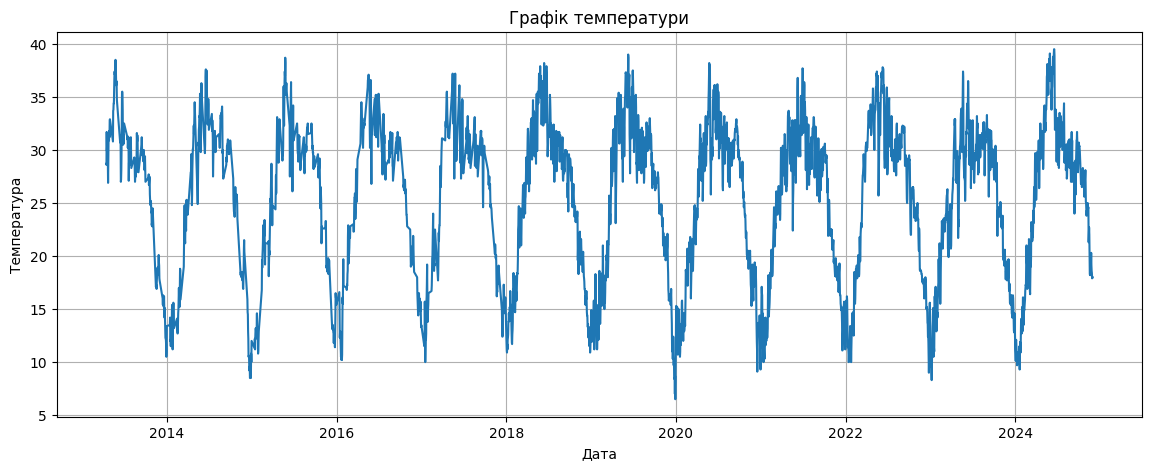

In [82]:
plt.figure(figsize=(14,5))
plt.plot(df["temp"])
plt.title("Графік температури")
plt.xlabel("Дата")
plt.ylabel("Температура")
plt.grid()
plt.show()


Ковзне середнє

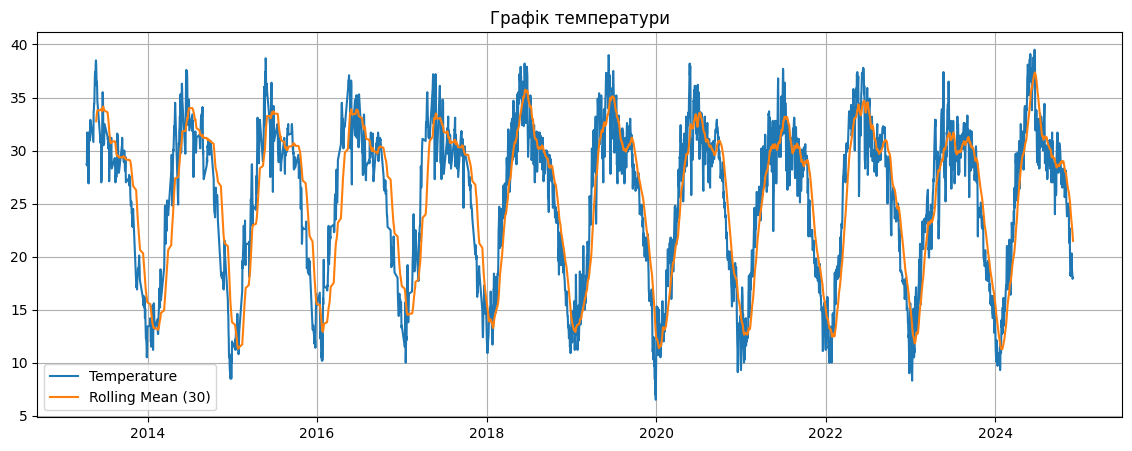

In [83]:
df["rolling_mean"] = df["temp"].rolling(window=30).mean()
plt.figure(figsize=(14,5))
plt.plot(df["temp"], label="Temperature")
plt.plot(df["rolling_mean"], label="Rolling Mean (30)")
plt.title("Графік температури")
plt.legend()
plt.grid()
plt.show()


Розподіл температури

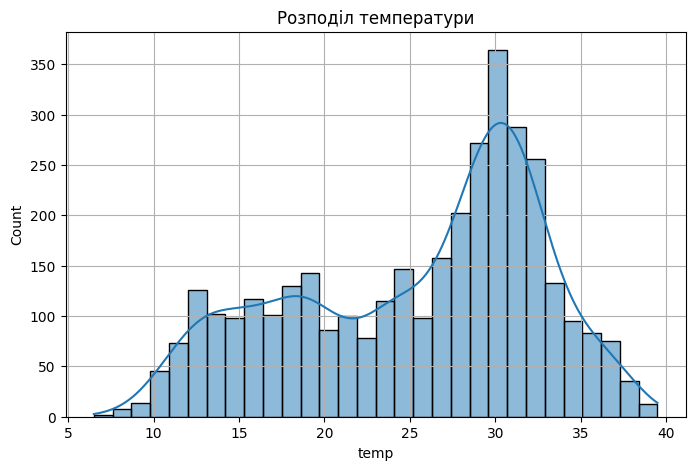

In [84]:
plt.figure(figsize=(8,5))
sns.histplot(df["temp"], bins=30, kde=True)
plt.title("Розподіл температури")
plt.grid()
plt.show()


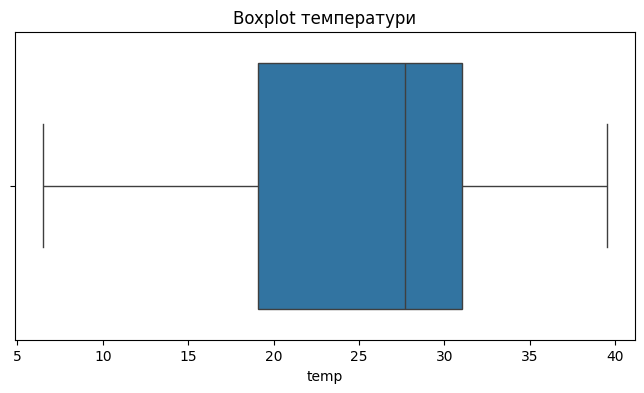

In [85]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["temp"])
plt.title("Boxplot температури")
plt.show()


Аналіз автокореляції
ACF

PACF

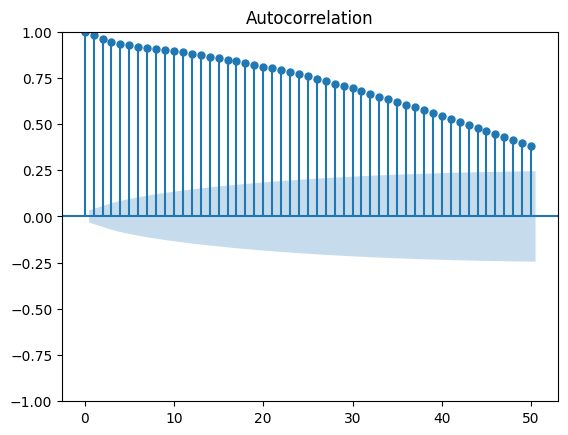

In [86]:
plot_acf(df["temp"], lags=50)
plt.show()

Автокореляційна функція (ACF) використовується для аналізу залежності значень часового ряду від його попередніх значень. Вона відображає ступінь кореляції між значенням показника у певний момент часу та значеннями цього самого показника у попередні моменти часу, які називаються лагами. Побудова графіка автокореляційної функції дозволяє виявити, чи існує статистично значуща залежність між поточним значенням ряду та його попередніми спостереженнями. На такому графіку по горизонтальній осі відкладаються лаги, тобто кількість часових кроків назад, а по вертикальній — значення коефіцієнта автокореляції. Аналіз графіка ACF дає можливість виявити наявність тренду, сезонності або інших закономірностей у часовому ряді, а також використовується для визначення параметрів статистичних моделей прогнозування, зокрема моделі ARIMA.

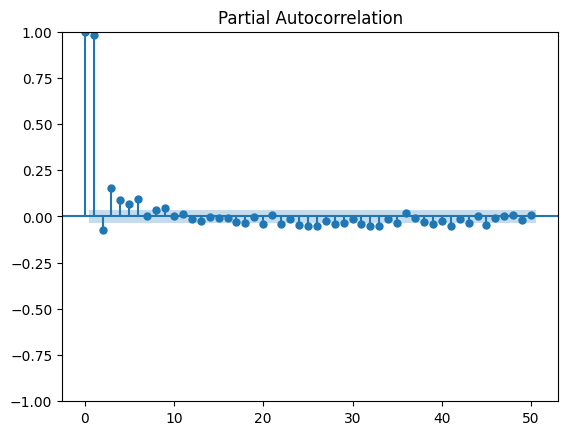

In [87]:
plot_pacf(df["temp"], lags=50)
plt.show()


Часткова автокореляційна функція (PACF) застосовується для більш точного визначення залежності між значеннями часового ряду. На відміну від звичайної автокореляційної функції, PACF вимірює кореляцію між значенням ряду у певний момент часу та значенням у попередній момент часу з конкретним лагом, усуваючи вплив усіх проміжних лагів. Таким чином, часткова автокореляція показує «чисту» залежність між двома спостереженнями часового ряду. Побудова графіка PACF дозволяє визначити, які саме лаги мають статистично значущий вплив на значення ряду. Це є важливим етапом під час побудови моделей прогнозування часових рядів, оскільки аналіз графіка часткової автокореляції використовується для визначення порядку авторегресійної складової моделі, зокрема параметра
𝑝
p у моделі ARIMA.

In [88]:
target = df["temp"].copy()
split_index = int(len(target) * 0.8)
train = target.iloc[:split_index]
test = target.iloc[split_index:]
print(f"Train shape:", len(train))
print(f"Test size:", len(test))

Train shape: 2845
Test size: 712


ARIMA

https://developer.ibm.com/tutorials/awb-arima-models-in-python/

In [89]:
train_arima = train.reset_index(drop=True)
arima_model = ARIMA(train_arima, order=(2, 1, 0))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast.index = test.index
print(arima_forecast.head())

DATE
2022-12-20    14.686378
2022-12-21    14.752056
2022-12-22    14.759303
2022-12-23    14.748899
2022-12-24    14.746902
Name: predicted_mean, dtype: float64


In [90]:
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   temp   No. Observations:                 2845
Model:                 ARIMA(2, 1, 0)   Log Likelihood               -5008.369
Date:                Wed, 07 Oct 2026   AIC                          10022.739
Time:                        08:27:41   BIC                          10040.598
Sample:                             0   HQIC                         10029.180
                               - 2845                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0757      0.016      4.858      0.000       0.045       0.106
ar.L2         -0.1668      0.017     -9.960      0.000      -0.200      -0.134
sigma2         1.9821      0.034     58.570      0.0

сигма 2 : це представляє дисперсію залишкових значень, чим менше, тим краще

логарифмічна правдоподібність : це оцінка максимальної правдоподібності для моделі ARIMA, чим вище, тим краще

aic : міра ступеню відповідності та економності моделі, чим нижче, тим краще

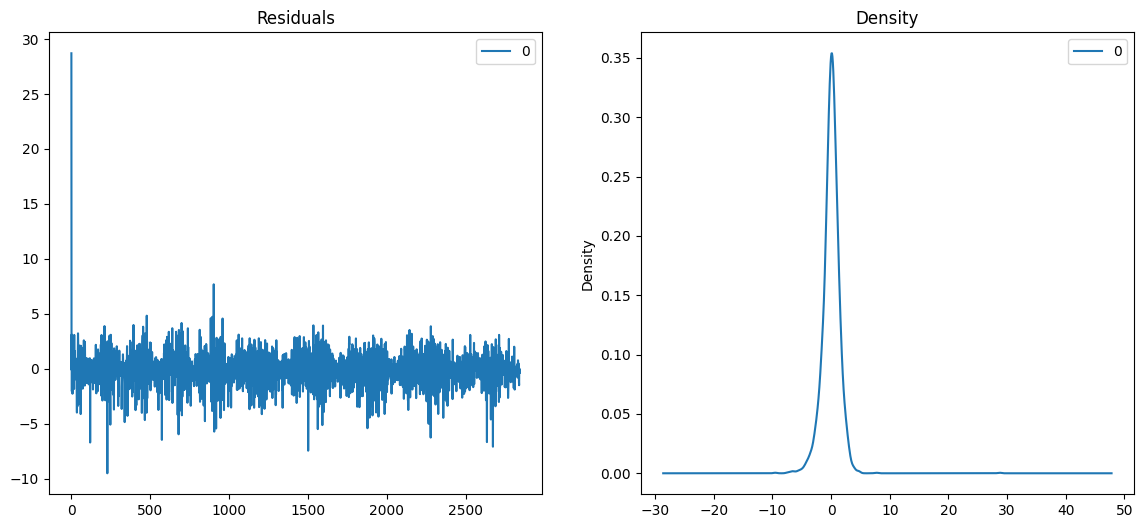

In [91]:
import pandas as pd
residuals = pd.DataFrame(arima_fit.resid)
fig, ax = plt.subplots(1,2, figsize=(14,6))
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()


In [122]:
def mape(y_true, y_pred):
  y_true = np.array(y_true)
  y_pred = np.array(y_pred)
  mask = y_true != 0
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = mean_squared_error(test, arima_forecast)
arima_mape = mape(test, arima_forecast)
print(f"MAE: {arima_mae}")
print(f"MSE: {arima_rmse}")
print(f"MAPE: {arima_mape}")

MAE: 11.24014781176335
MSE: 164.81446966876527
MAPE: 40.5826462216903


In [124]:
def mape(y_true, y_pred):
  y_true = np.array(y_true)
  y_pred = np.array(y_pred)
  mask = y_true != 0
  return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = mean_squared_error(test, arima_forecast)
arima_mape = mape(test, arima_forecast)
print(f"MAE: {arima_mae}")
print(f"MSE: {arima_rmse}")
print(f"MAPE: {arima_mape}")

MAE: 11.24014781176335
MSE: 164.81446966876527
MAPE: 40.5826462216903


PROPHET

https://facebook.github.io/prophet/docs/quick_start.html

In [125]:
prophet_df = df.reset_index()[["DATE", "temp"]].copy()
prophet_df.columns = ["ds", "y"]
prophet_train = prophet_df.iloc[:split_index].copy()
prophet_test = prophet_df.iloc[split_index:].copy()



In [126]:
from prophet import Prophet
prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True

)
prophet_model.fit(prophet_train)

Прогноз

In [127]:
future = prophet_model.make_future_dataframe(periods=len(test), freq='D')
forecast_forecast_full = prophet_model.predict(future)
prophet_forecast = forecast_forecast_full[["ds","yhat"]].tail(len(prophet_test)).copy()
prophet_forecast = prophet_forecast.set_index("ds")
prophet_test_indexed = prophet_test.set_index("ds")

In [128]:
prophet_mae = mean_absolute_error(prophet_test_indexed["y"], prophet_forecast["yhat"])
prophet_rmse = np.sqrt(mean_squared_error(prophet_test_indexed["y"], prophet_forecast["yhat"]))
prophet_mape = mape(prophet_test_indexed["y"], prophet_forecast["yhat"])
print("MAE:", prophet_mae)
print("MSE:", prophet_rmse)
print("MAPE:", prophet_mape)


MAE: 2.004679994301011
MSE: 2.5901965298397274
MAPE: 9.027934868552647


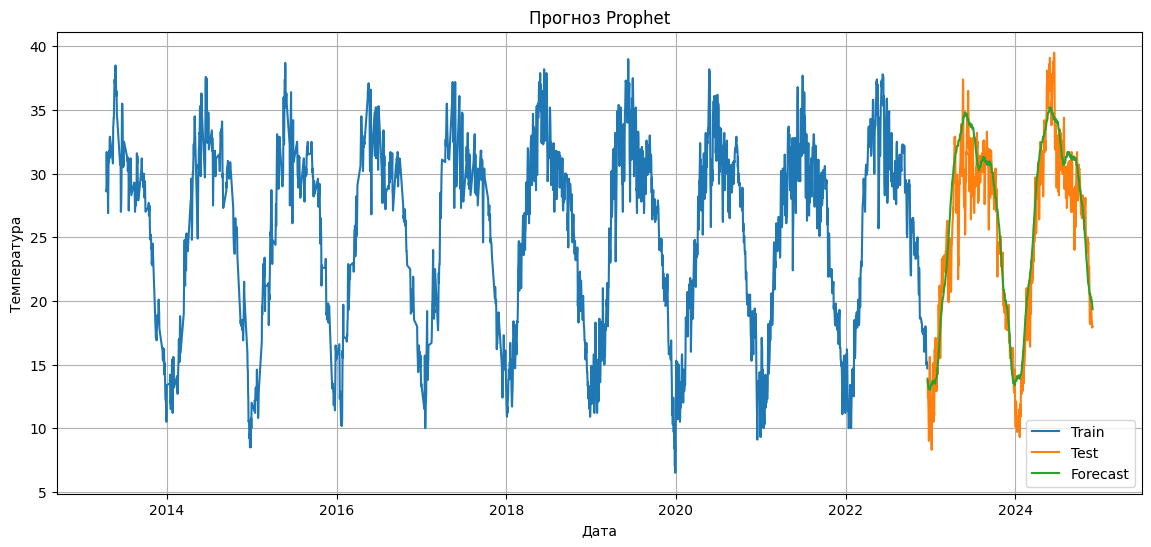

In [129]:
plt.figure(figsize=(14, 6))
plt.plot(prophet_train["ds"], prophet_train["y"], label="Train")
plt.plot(prophet_test["ds"], prophet_test["y"], label="Test")
plt.plot(prophet_forecast.index, prophet_forecast["yhat"], label="Forecast")
plt.title("Прогноз Prophet")
plt.xlabel("Дата")
plt.ylabel("Температура")
plt.legend()
plt.grid()
plt.show()

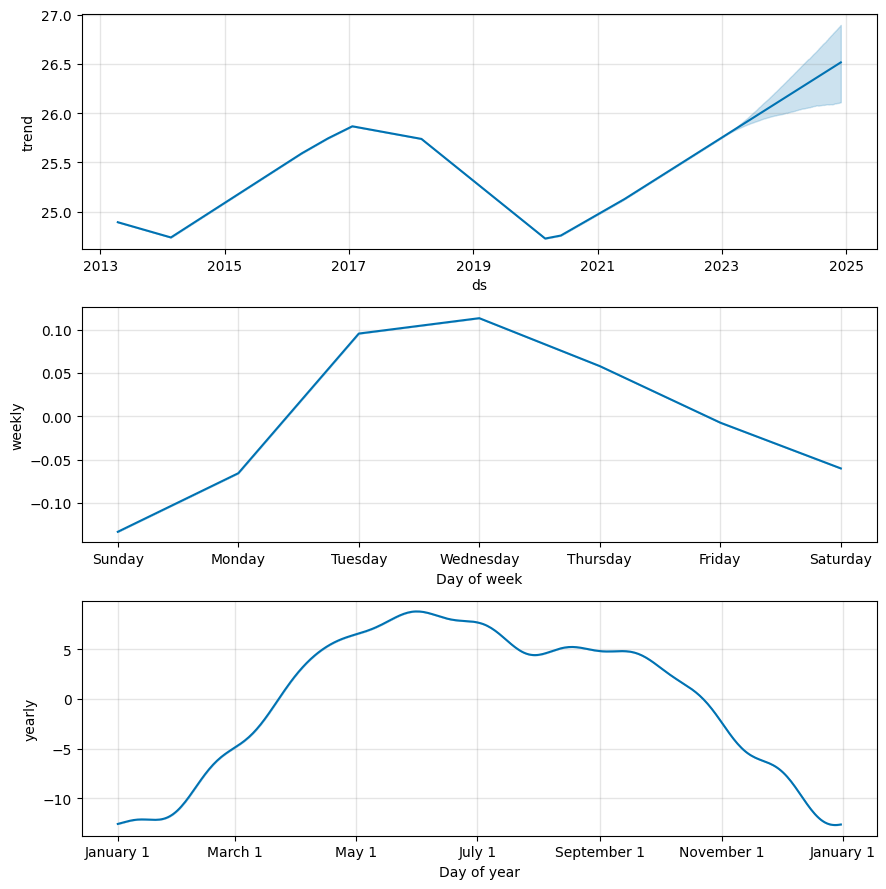

In [130]:
prophet_model.plot_components(forecast_forecast_full)
plt.show()

ПІДГОТОВКА ДАНИХ ДЛЯ LSTM

In [131]:
scaler = MinMaxScaler()
scaler_values = scaler.fit_transform(df[["temp"]])
sequence_length = 30
X = []
y = []
for i in range(sequence_length, len(scaler_values)):
    X.append(scaler_values[i - sequence_length:i, 0])
    y.append(scaler_values[i, 0])
X = np.array(X)
y = np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (3527, 30, 1)
y shape: (3527,)


In [132]:
split_lstm = int(len(X) * 0.8)
X_train = X[:split_lstm]
X_test = X[split_lstm:]
y_train = y[:split_lstm]
y_test = y[split_lstm:]
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (2821, 30, 1)
X_test shape: (706, 30, 1)


In [133]:
lstm_model = Sequential()
lstm_model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
lstm_model.add(LSTM(50))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer="adam", loss="mse")


In [134]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1,

)


Epoch 1/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - loss: 0.0245 - val_loss: 0.0050
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0056 - val_loss: 0.0045
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0051 - val_loss: 0.0042
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0048 - val_loss: 0.0041
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 6/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0046 - val_loss: 0.0048
Epoch 7/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0044 - val_loss: 0.0038
Epoch 8/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0043 - val_loss: 0.0033
Epoch 9/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0040 - val_loss: 0.0032
Epoch 10/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0037 - val_loss: 0.0029
Epoch 11/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0035 - val_loss: 0.0037
Epoch 12/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0

In [135]:
lstm_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,955 (359.20 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 61,304 (239.47 KB)

In [136]:
lstm_rped_scaled = lstm_model.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_rped_scaled)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


In [137]:
lstm_dates = df.index[sequence_length:][split_lstm:]


In [138]:
lstm_mae = mean_absolute_error(y_test_real, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_real, lstm_pred))
lstm_mape = mape(y_test_real.flatten(), lstm_pred.flatten())
print("MAE:", lstm_mae)
print("MSE:", lstm_rmse)
print("MAPE:", lstm_mape)


MAE: 1.1867563647521453
MSE: 1.5519953841324512
MAPE: 5.25482208985408


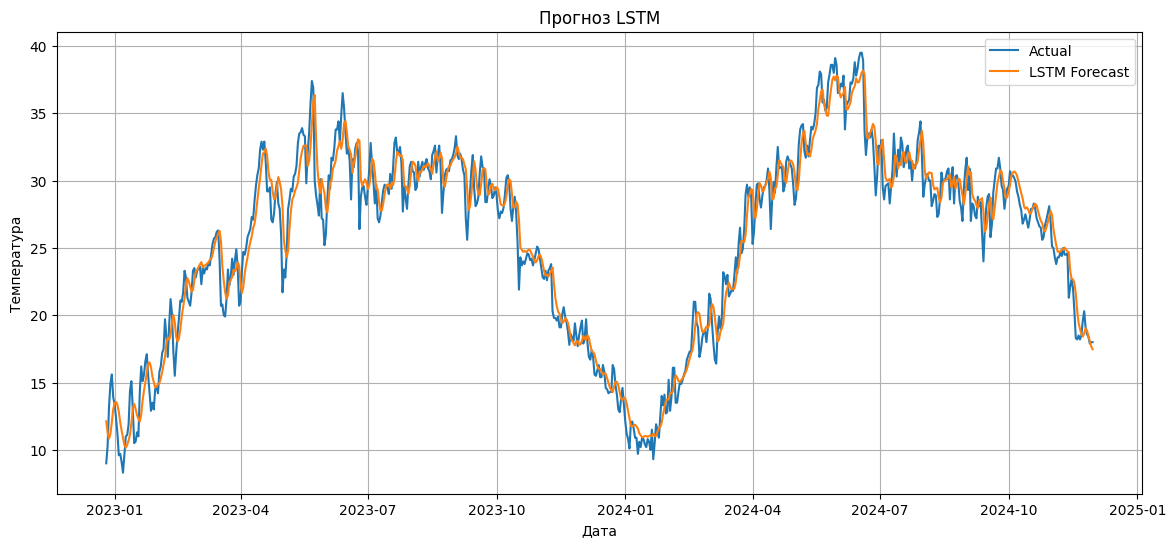

In [139]:
plt.figure(figsize=(14, 6))
plt.plot(lstm_dates, y_test_real, label="Actual")
plt.plot(lstm_dates, lstm_pred, label="LSTM Forecast")
plt.title("Прогноз LSTM")
plt.xlabel("Дата")
plt.ylabel("Температура")
plt.legend()
plt.grid()
plt.show()


Порівняння моделей

In [143]:
results = pd.DataFrame({
    "Model": ["ARIMA", "Prophet", "LSTM"],
    "MAE": [arima_mae, prophet_mae, lstm_mae],
    "RMSE": [arima_rmse, prophet_rmse, lstm_rmse],
    "MAPE": [arima_mape, prophet_mape, lstm_mape]
})
print(results.sort_values("RMSE"))

     Model        MAE        RMSE       MAPE
2     LSTM   1.186756    1.551995   5.254822
1  Prophet   2.004680    2.590197   9.027935
0    ARIMA  11.240148  164.814470  40.582646


## Висновок

Сформулюйте висновок за результатами роботи: коротко охарактеризуйте виконаний аналіз, порівняйте моделі ARIMA, Prophet та LSTM за метриками MAE, RMSE і MAPE та зазначте, яка модель продемонструвала найкращу якість прогнозування.
